# CFSPMNet SPPM training: two-stage adaptation smoke test

This notebook ports the **Shared-Private Prototype Matching (SPPM)** two-stage
training loop (`temp/sppm_strategy.py`, CFSPMNet paper section 2.3-2.4) into
`src/eeg_bci/cfspmnet/{canonicalization,sppm,datasets,training}.py`, and
verifies it end to end on a **cheap 3-subject fold** (subjects 1-2 as
labeled source, subject 3 as the unlabeled adaptation/held-out target) before
committing to the full 50-subject LOSO sweep in
`03_cfspmnet_loso_evaluation.ipynb`.

Two canonicalization steps make different Liu2024 patients comparable (see
`eeg_bci.cfspmnet.canonicalization`):
1. **Label remap** -- `left_hand`/`right_hand` -> `affected`/`unaffected`,
   using each subject's `ParalysisSide` from `participants.tsv`.
2. **Channel flip** -- left-paralysis subjects get their left/right channel
   pairs swapped (`FC3<->FC4`, `C3<->C4`, ...) so "affected hemisphere" is
   always spatially on the same side. This is what makes SPPM's
   private-signature channel groups (fixed left/right motor triplets, see
   `eeg_bci.cfspmnet.sppm`) meaningful across subjects.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from omegaconf import OmegaConf


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")


repo_root = find_repo_root(Path.cwd().resolve())
repo_root

PosixPath('/workspaces/BRAINDECODE')

## 1. Load clinical metadata + build the 3-subject smoke fold

`build_loso_fold` (a) applies the channel-flip + label-remap canonicalization
per subject, (b) uses the project's existing leakage-safe
`_chronological_split_indices` (`eeg_bci.data.splitting.sources`) to split
the held-out subject into an unlabeled adaptation partition and an untouched
test partition, and (c) returns ready-to-train datasets. This mirrors the
protocol already validated in `notebooks/liu2024_figshare.ipynb`.

In [2]:
from eeg_bci.cfspmnet.canonicalization import load_liu2024_participants
from eeg_bci.cfspmnet.datasets import (
    build_loso_fold,
    chronological_adapt_test_indices,
    materialize_canonical_trials,
)
from eeg_bci.data.moabb import build_moabb_dataset

participants = load_liu2024_participants(
    repo_root / "data/moabb/MNE-liu2024-data/files/participants.tsv"
)

dataset_cfg = OmegaConf.load(repo_root / "configs/dataset/liu2024.yaml")
preprocessing_cfg = OmegaConf.load(repo_root / "configs/preprocessing/liu2024.yaml")
dataset_cfg.subject_ids = [1, 2, 3]  # smoke-scale: 2 source subjects, 1 held-out target
windows, dataset_info = build_moabb_dataset(dataset_cfg, preprocessing_cfg)
metadata = windows.get_metadata().reset_index(drop=True)

canonical_x, canonical_y, subject_ids = materialize_canonical_trials(windows, metadata, participants)
adapt_idx_all, test_idx_all = chronological_adapt_test_indices(windows, test_size=0.2, stratify=True)

HELD_OUT_SUBJECT = 3
fold = build_loso_fold(
    canonical_x, canonical_y, subject_ids, adapt_idx_all, test_idx_all, held_out_subject=HELD_OUT_SUBJECT
)

assert len(fold.source_dataset) == 80  # subjects 1+2, 40 trials each
assert len(fold.target_adapt_dataset) == 32  # subject 3, 80% chronologically first
assert len(fold.target_test_dataset) == 8  # subject 3, untouched final 20%
print(
    f"PASS: fold sizes -> source={len(fold.source_dataset)}, "
    f"target_adapt={len(fold.target_adapt_dataset)}, target_test={len(fold.target_test_dataset)}"
)

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)
/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(


PASS: fold sizes -> source=80, target_adapt=32, target_test=8


## 2. Stage I: source-supervised pretraining

Plain cross-entropy training on the labeled source subjects only
(`train_source_only_epoch`), matching the paper's Stage I.

In [3]:
from eeg_bci.cfspmnet.model import CFSPMNet
from eeg_bci.cfspmnet.training import build_sppm_dataloaders, train_source_only_epoch
from eeg_bci.utils.seed import seed_everything

seed_everything(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CFSPMNet.from_dataset_info(dataset_info).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

source_loader, target_adapt_loader, target_test_loader, target_init_loader = build_sppm_dataloaders(
    fold.source_dataset, fold.target_adapt_dataset, fold.target_test_dataset, batch_size=16
)

STAGE_I_EPOCHS = 15
for epoch in range(STAGE_I_EPOCHS):
    source_loss = train_source_only_epoch(source_loader, model, optimizer, device)
    if epoch % 5 == 0 or epoch == STAGE_I_EPOCHS - 1:
        print(f"stage I epoch {epoch:2d}: source_loss={source_loss:.4f}")
print("PASS: Stage I source-only pretraining completed")

/workspaces/BRAINDECODE/.venv/lib/python3.11/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(


stage I epoch  0: source_loss=0.9026
stage I epoch  5: source_loss=0.7365
stage I epoch 10: source_loss=0.6909
stage I epoch 14: source_loss=0.6713
PASS: Stage I source-only pretraining completed


## 3. Shared-private prototype construction (Eq. 8)

Builds class-level shared prototypes `c_k` and class-wise matching
tolerances `delta_k` from the source subjects' private-signature features
(`compute_private_signature_features`, Eq. 9).

Note: the paper's XW-Stroke `matching_tolerance_floor` is **0.50** (used in
the full 50-subject run in `03_cfspmnet_loso_evaluation.ipynb`). With only 2
source subjects here, the computed `mean - std` tolerance is naturally noisier
and lower, so this smoke test uses a relaxed floor (**0.30**) purely to
demonstrate the acceptance mechanism firing on so little source data -- not
as a claim that 0.30 is the right operating point.

In [4]:
from eeg_bci.cfspmnet.sppm import build_shared_private_signature_prototypes

SMOKE_MATCHING_TOLERANCE_FLOOR = 0.30

shared_prototypes, class_wise_matching_tolerance = build_shared_private_signature_prototypes(
    fold.source_signature_vectors, fold.source_labels, num_classes=2, floor=SMOKE_MATCHING_TOLERANCE_FLOOR
)
shared_prototypes_t = torch.as_tensor(shared_prototypes, dtype=torch.float32, device=device)
tolerance_t = torch.as_tensor(class_wise_matching_tolerance, dtype=torch.float32, device=device)

print(f"class-wise matching tolerances (affected, unaffected): {class_wise_matching_tolerance}")
assert shared_prototypes.shape[0] == 2
print("PASS: shared prototypes + matching tolerances built from source private signatures")

class-wise matching tolerances (affected, unaffected): [0.45528582 0.46908778]
PASS: shared prototypes + matching tolerances built from source private signatures


## 4. Initialize target pseudo-labels

Before Stage II, run the (frozen) Stage-I model once over the target-adaptation
partition to seed pseudo-labels via calibrated matching (semantic confidence
AND private-signature consistency, Eq. 10).

In [5]:
from eeg_bci.cfspmnet.training import SPPMTrainingConfig, initialize_target_pseudo_labels

cfg = SPPMTrainingConfig(device=device, alpha=0.98, pseudo_threshold=0.60, use_private_signature_matching=True)

initial_accepted_ratio, initial_matching_stats = initialize_target_pseudo_labels(
    cfg, model, target_init_loader, shared_prototypes_t, tolerance_t
)
assert 0.0 <= initial_accepted_ratio <= 1.0
print(f"PASS: initial accepted_ratio={initial_accepted_ratio:.3f} over {len(fold.target_adapt_dataset)} target windows")
initial_matching_stats

PASS: initial accepted_ratio=0.031 over 32 target windows


{'accepted_count': 1,
 'rejected_count': 31,
 'accepted_confidence': 0.6694381833076477,
 'rejected_confidence': 0.5847712639839419,
 'accepted_entropy': 0.6345757842063904,
 'rejected_entropy': 0.6708809252708189}

## 5. Stage II: joint source supervision + SPPM-calibrated target adaptation

Each epoch alternates source-labeled and target-pseudo-labeled batches
(`train_sppm_epoch`), refreshing pseudo-labels after every optimizer step
(paper: "dynamic pseudo-label updating", the single largest ablation
contributor in Table 5).

In [6]:
from eeg_bci.cfspmnet.training import train_sppm_epoch

STAGE_II_EPOCHS = 10
stage_ii_history = []
for epoch in range(STAGE_II_EPOCHS):
    stats = train_sppm_epoch(
        cfg, source_loader, target_adapt_loader, model, optimizer, shared_prototypes_t, tolerance_t
    )
    stage_ii_history.append(stats)
    assert 0.0 <= stats["accepted_ratio"] <= 1.0
    assert 0.0 <= stats["active_ratio"] <= 1.0
    print(
        f"stage II epoch {epoch:2d}: train_loss={stats['train_loss']:.4f} "
        f"accepted_ratio={stats['accepted_ratio']:.2f} active_ratio={stats['active_ratio']:.2f}"
    )
print("PASS: Stage II adaptation ran for all epochs with ratios in [0, 1]")

stage II epoch  0: train_loss=0.6818 accepted_ratio=0.11 active_ratio=0.16
stage II epoch  1: train_loss=0.5908 accepted_ratio=0.06 active_ratio=0.16
stage II epoch  2: train_loss=0.5468 accepted_ratio=0.06 active_ratio=0.16
stage II epoch  3: train_loss=0.5723 accepted_ratio=0.07 active_ratio=0.16
stage II epoch  4: train_loss=0.5301 accepted_ratio=0.06 active_ratio=0.16
stage II epoch  5: train_loss=0.5240 accepted_ratio=0.07 active_ratio=0.16
stage II epoch  6: train_loss=0.5230 accepted_ratio=0.07 active_ratio=0.16
stage II epoch  7: train_loss=0.4973 accepted_ratio=0.10 active_ratio=0.16
stage II epoch  8: train_loss=0.4448 accepted_ratio=0.06 active_ratio=0.16
stage II epoch  9: train_loss=0.4156 accepted_ratio=0.10 active_ratio=0.16
PASS: Stage II adaptation ran for all epochs with ratios in [0, 1]


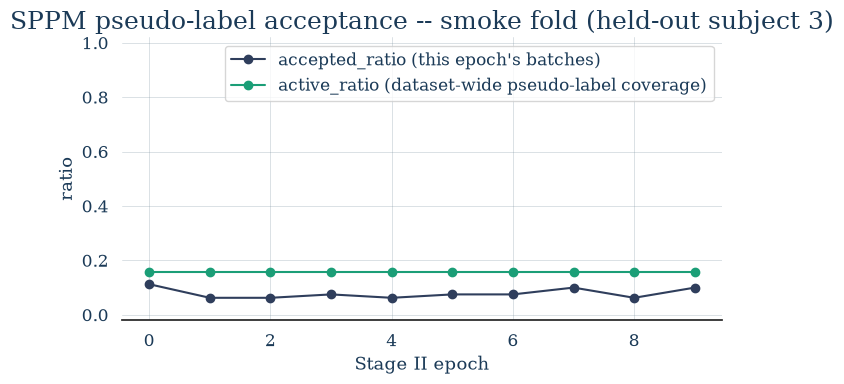

In [7]:
epochs = list(range(STAGE_II_EPOCHS))
accepted = [h["accepted_ratio"] for h in stage_ii_history]
active = [h["active_ratio"] for h in stage_ii_history]

plt.figure(figsize=(7, 4))
plt.plot(epochs, accepted, marker="o", label="accepted_ratio (this epoch's batches)")
plt.plot(epochs, active, marker="o", label="active_ratio (dataset-wide pseudo-label coverage)")
plt.xlabel("Stage II epoch")
plt.ylabel("ratio")
plt.ylim(-0.02, 1.02)
plt.title(f"SPPM pseudo-label acceptance -- smoke fold (held-out subject {HELD_OUT_SUBJECT})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evaluate on the untouched target-test partition

`evaluate_target` never sees these 8 windows during Stage I or Stage II --
they are the leakage-safe chronological holdout from Part 1. Metrics reuse
`eeg_bci.tracking.metrics.compute_metrics`, the same multi-class-safe
implementation every other training script in this project uses.

In [8]:
from eeg_bci.cfspmnet.training import evaluate_target

result = evaluate_target(model, target_test_loader, device, dataset_info.n_outputs)
metrics = result["metrics"]

assert all(torch.isfinite(torch.tensor(float(v))) for k, v in metrics.items() if k != "confusion_matrix")
print(f"PASS: evaluated on {result['n_test_windows']} held-out target windows")
{k: v for k, v in metrics.items() if k != "confusion_matrix"}

PASS: evaluated on 8 held-out target windows


{'accuracy': 0.375,
 'balanced_accuracy': 0.375,
 'cohen_kappa': -0.25,
 'macro_f1': 0.2727272727272727,
 'macro_precision': 0.21428571428571427,
 'macro_recall': 0.375,
 'roc_auc': 0.25}

## Conclusion

The full two-stage SPPM loop -- source pretraining, shared-prototype
construction, pseudo-label initialization, calibrated dynamic pseudo-label
adaptation, and held-out evaluation -- runs end to end without error, and
every ratio/metric stays in its valid range. With only 2 source subjects the
pseudo-label acceptance rate is necessarily sparse and noisy (expected: SPPM's
shared prototypes are source-pool statistics, and 2 subjects is a tiny pool).
`03_cfspmnet_loso_evaluation.ipynb` scales this to the full 49-source-subject
LOSO sweep using the paper's actual XW-Stroke hyperparameters
(`matching_tolerance_floor=0.50`, `Stage-I epochs=25`).

Note the target-test accuracy printed above is computed on only 8 windows
from a model pretrained on 2 source subjects -- it is a mechanism check, not
a meaningful accuracy estimate (chance-level noise at n=8 is +/-35 points).
Treat only the full LOSO sweep's aggregate numbers as informative.